# **Anomaly Detection in Mobile API Traffic**
## Deep Autoencoder : Unsupervised Anomaly Detection
--- 

## Why an Autoencoder?

An Autoencoder is a neural network trained to **compress then reconstruct** its input.
When trained only on normal data, it learns a compact representation of what normal
API behavior looks like.

When it sees an anomalous window, it fails to reconstruct it accurately — the
**reconstruction error is high**. This error becomes our anomaly score.

> Normal window  →  low reconstruction error  ✅
> Anomalous window  →  high reconstruction error  🚨
---
## Why not a supervised model?

Supervised models (like Random Forest or XGBoost) require **labeled examples of anomalies**
to learn from. In production, anomalies are so rare that we rarely have enough labeled
examples. The Autoencoder solves this : it only needs normal data to train.

## **Step 1 : Imports & Global Configuration**

We start by importing all the libraries we need :
- **TensorFlow / Keras** : for building and training the Autoencoder
- **NumPy / Pandas** : for data manipulation
- **scikit-learn** : for evaluation metrics (F1, AUC, confusion matrix)
- **Matplotlib / Seaborn** : for plotting results
- **pickle** : for loading the saved scaler from the ETL notebook

In [49]:
import os
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]  = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

os.makedirs("../report", exist_ok=True)

EPOCHS  = 100
BATCH_SIZE  = 32
LEARNING_RATE = 1e-3
l2_reg = 1e-4
PATIENCE = 10       # EarlyStopping patience
THRESHOLD_PCT = 95       # percentile used to define the anomaly threshold

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Seed : {SEED}")
print(f"Epochs (max) : {EPOCHS}")
print(f"Batch size : {BATCH_SIZE}")
print(f"Learning rate  : {LEARNING_RATE}")

TensorFlow version : 2.21.0
GPU available : False
Seed : 42
Epochs (max) : 100
Batch size : 32
Learning rate  : 0.001


## **Step 2 : Load Data from ETL Notebook**

The ETL notebook produced 4 files that we load here :

| File | Content |
|---|---|
| `X_scaled.csv` | Normalized features — input to the Autoencoder |
| `y_labels.csv` | Binary anomaly labels (0 = normal, 1 = anomaly) |
| `y_labels_clean.csv` | Same labels but with Warning zone set to NaN |
| `scaler.pkl` | Fitted StandardScaler — for inverse-transforming data |

We use `y_labels_clean` for evaluation because it excludes borderline cases, which makes our metrics more honest.

In [94]:
# APRÈS
X_raw  = pd.read_csv("../data/X_raw.csv")      # brut, pas encore normalisé
y  = pd.read_csv("../data/y_labels.csv").squeeze()
y_clean = pd.read_csv("../data/y_labels_clean.csv").squeeze()

print("Data loaded successfully")
print(f"\nX_raw shape  : {X_raw.shape}")
print(f"y shape      : {y.shape}")
print(f"\nLabel distribution :")
print(y.value_counts().rename({0: "Normal", 1: "Anomaly"}))
print(f"\nTaux d'anomalies : {y.mean()*100:.1f}%")

Data loaded successfully

X_raw shape  : (4443, 46)
y shape      : (4443,)

Label distribution :
is_anomaly
Normal     4249
Anomaly     194
Name: count, dtype: int64

Taux d'anomalies : 4.4%


## Step 3 : Train / Validation / Test Split

The split strategy for an Autoencoder is different from a supervised model :

- **Train set** : normal windows ONLY — the model learns what normal looks like
- **Validation set** : normal windows ONLY — used to monitor reconstruction loss during training
- **Test set** : normal + anomalies — used to evaluate final detection performance

We first split 80% train / 20% test on the full dataset, then isolate
normal-only windows from the train set for actual Autoencoder training.

> **Why train only on normal data?**
> If we train on anomalies too, the model learns to reconstruct them well,
> which destroys the detection signal. The whole mechanism relies on the
> model being "surprised" by anomalies.

In [73]:
# ── Split temporel : pas de mélange passé/futur ──────────────
n = len(X_raw)
test_start  = int(n * 0.80)
val_start   = int(n * 0.64)

# Test : les 20% les plus récents
X_test       = X_raw.iloc[test_start:].reset_index(drop=True)
y_test       = y.iloc[test_start:].reset_index(drop=True)
y_test_clean = y_clean.iloc[test_start:].reset_index(drop=True)

# Train+Val : les 80% les plus anciens
X_train_full = X_raw.iloc[:test_start]
y_train_full = y.iloc[:test_start]

# Validation
X_val_full       = X_train_full.iloc[val_start:]
X_train_full_cut = X_train_full.iloc[:val_start]
y_train_cut      = y_train_full.iloc[:val_start]

# Normaux seulement pour l'autoencoder
X_train_normal = X_train_full_cut[y_train_cut == 0].reset_index(drop=True)
X_val_normal   = X_val_full[y_train_full.iloc[val_start:] == 0].reset_index(drop=True)

# Split train normal 80/20
n_train = len(X_train_normal)
val_keras_start = int(n_train * 0.80)
X_train = X_train_normal.iloc[:val_keras_start].reset_index(drop=True)
X_val   = X_train_normal.iloc[val_keras_start:].reset_index(drop=True)

print("Split temporel appliqué")
print(f"Train (normal only)  : {X_train.shape}")
print(f"Validation (normal)  : {X_val.shape}")
print(f"Test (normal+anomaly): {X_test.shape}")
print(f"Anomalies in test    : {y_test.sum()} ({y_test.mean()*100:.1f}%)")
'''
# ── Scaler fitté ICI sur train uniquement ─────────────────────
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train).astype("float32")   # fit + transform
X_val_np   = scaler.transform(X_val).astype("float32")         # transform seulement
X_test_np  = scaler.transform(X_test).astype("float32")        # transform seulement

# Sauvegarder le scaler correctement fitté
with open("../data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
'''
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_np = scaler.fit_transform(X_train).astype("float32")
X_val_np   = scaler.transform(X_val).astype("float32")
X_test_np  = scaler.transform(X_test).astype("float32")

with open("../data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ RobustScaler appliqué")
print(f"\nValeurs après RobustScaler (X_test) :")
X_test_scaled_df = pd.DataFrame(X_test_np, columns=X_test.columns)
extreme_scaled = X_test_scaled_df.describe().T[["min", "max"]].copy()
extreme_scaled["abs_max"] = extreme_scaled[["min", "max"]].abs().max(axis=1)
print(extreme_scaled.sort_values("abs_max", ascending=False).head(10))
INPUT_DIM = X_train_np.shape[1]
print(f"\n✅ Scaler fitté sur train uniquement — no leakage")
print(f"Input dimension : {INPUT_DIM} features")

Split temporel appliqué
Train (normal only)  : (2166, 46)
Validation (normal)  : (542, 46)
Test (normal+anomaly): (889, 46)
Anomalies in test    : 34 (3.8%)
✅ RobustScaler appliqué

Valeurs après RobustScaler (X_test) :
                           min         max     abs_max
latency_spike         0.000000  936.880005  936.880005
std_response_time     0.000000  852.770752  852.770752
quality_degradation  -0.295813  430.721039  430.721039
avg_bytes_sent       -0.414044  104.690521  104.690521
total_bytes_sent     -0.384771   91.102394   91.102394
severity_error        0.000000   50.000000   50.000000
max_severity          0.000000   49.555698   49.555698
combined_severity     0.000000   49.000000   49.000000
stress_score         -0.582740   12.446556   12.446556
median_response_time -0.582740   12.446556   12.446556

✅ Scaler fitté sur train uniquement — no leakage
Input dimension : 46 features


In [95]:
# ── Split temporel : pas de mélange passé/futur ──────────────
n = len(X_raw)
test_start  = int(n * 0.80)
val_start   = int(n * 0.64)

X_test       = X_raw.iloc[test_start:].reset_index(drop=True)
y_test       = y.iloc[test_start:].reset_index(drop=True)
y_test_clean = y_clean.iloc[test_start:].reset_index(drop=True)

X_train_full = X_raw.iloc[:test_start]
y_train_full = y.iloc[:test_start]

X_val_full       = X_train_full.iloc[val_start:]
X_train_full_cut = X_train_full.iloc[:val_start]
y_train_cut      = y_train_full.iloc[:val_start]

X_train_normal = X_train_full_cut[y_train_cut == 0].reset_index(drop=True)
X_val_normal   = X_val_full[y_train_full.iloc[val_start:] == 0].reset_index(drop=True)

n_train = len(X_train_normal)
val_keras_start = int(n_train * 0.80)
X_train = X_train_normal.iloc[:val_keras_start].reset_index(drop=True)
X_val   = X_train_normal.iloc[val_keras_start:].reset_index(drop=True)

print("Split temporel appliqué")
print(f"Train (normal only)  : {X_train.shape}")
print(f"Validation (normal)  : {X_val.shape}")
print(f"Test (normal+anomaly): {X_test.shape}")
print(f"Anomalies in test    : {y_test.sum()} ({y_test.mean()*100:.1f}%)")


# ══════════════════════════════════════════════════════════════
# ── Clipping CIBLÉ — uniquement la colonne buggée ─────────────
# ══════════════════════════════════════════════════════════════

COLS_TO_CLIP = ["quality_degradation"]

def clip_specific_columns(df, columns, lower_q=0.01, upper_q=0.99, bounds=None):
    df_clipped = df.copy()
    if bounds is None:
        bounds = {}
        for col in columns:
            low  = df[col].quantile(lower_q)
            high = df[col].quantile(upper_q)
            bounds[col] = (low, high)

    for col in columns:
        low, high = bounds[col]
        df_clipped[col] = df_clipped[col].clip(lower=low, upper=high)

    return df_clipped, bounds


X_train_clipped, clip_bounds = clip_specific_columns(X_train, COLS_TO_CLIP)
X_val_clipped, _  = clip_specific_columns(X_val,  COLS_TO_CLIP, bounds=clip_bounds)
X_test_clipped, _ = clip_specific_columns(X_test, COLS_TO_CLIP, bounds=clip_bounds)

print(f"\n✅ Clipping appliqué uniquement sur : {COLS_TO_CLIP}")
print(f"quality_degradation — max avant : {X_test['quality_degradation'].max():.1f}")
print(f"quality_degradation — max après : {X_test_clipped['quality_degradation'].max():.1f}")


# ══════════════════════════════════════════════════════════════
# ── Scaler fitté sur train (clippé sur 1 colonne) uniquement ──
# ══════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train_clipped).astype("float32")
X_val_np   = scaler.transform(X_val_clipped).astype("float32")
X_test_np  = scaler.transform(X_test_clipped).astype("float32")

with open("../data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../data/clip_bounds.pkl", "wb") as f:
    pickle.dump(clip_bounds, f)

INPUT_DIM = X_train_np.shape[1]
print(f"\n✅ Scaler fitté — no leakage")
print(f"Input dimension : {INPUT_DIM} features")

print(f"\n=== Vérification valeurs extrêmes après clip ciblé + scale ===")
X_test_scaled_df = pd.DataFrame(X_test_np, columns=X_test.columns)
extreme_scaled = X_test_scaled_df.describe().T[["min", "max"]].copy()
extreme_scaled["abs_max"] = extreme_scaled[["min", "max"]].abs().max(axis=1)
print(extreme_scaled.sort_values("abs_max", ascending=False).head(10))

print(f"\n=== Vérifier que les anomalies gardent leur signal (severity_*) ===")
anomaly_mask = y_test.values == 1
print(X_test_scaled_df.loc[anomaly_mask, ["max_severity", "combined_severity"]].describe())

Split temporel appliqué
Train (normal only)  : (2166, 46)
Validation (normal)  : (542, 46)
Test (normal+anomaly): (889, 46)
Anomalies in test    : 34 (3.8%)

✅ Clipping appliqué uniquement sur : ['quality_degradation']
quality_degradation — max avant : 196200.0
quality_degradation — max après : 58740.0

✅ Scaler fitté — no leakage
Input dimension : 46 features

=== Vérification valeurs extrêmes après clip ciblé + scale ===
                           min         max     abs_max
max_severity         -0.389490  341.372162  341.372162
severity_error        0.000000   50.000000   50.000000
combined_severity     0.000000   49.000000   49.000000
avg_bytes_sent       -0.497183   43.966335   43.966335
total_bytes_sent     -0.499847   39.269871   39.269871
latency_spike        -0.218083   19.096455   19.096455
std_response_time    -0.218083   11.964622   11.964622
median_response_time -0.809189    9.512886    9.512886
avg_response_time    -0.809189    9.512886    9.512886
stress_score         -0

In [93]:
print("=== Colonnes avec ratio max/median très élevé (signe de bug numérique) ===")
for col in X_train.select_dtypes(include=[np.number]).columns:
    median = X_train[col].median()
    max_val = X_train[col].max()
    if median > 0:
        ratio = max_val / median
        if ratio > 500:
            print(f"  {col} : median={median:.2f}, max={max_val:.2f}, ratio={ratio:.0f}x")

=== Colonnes avec ratio max/median très élevé (signe de bug numérique) ===
  quality_degradation : median=136.63, max=143000.00, ratio=1047x


## **Step 4 : Autoencoder Architecture**

The Autoencoder has two parts :

### Encoder
Compresses the input from `INPUT_DIM` features down to a bottleneck of 8 neurons.
This bottleneck forces the model to learn a compact representation of normal behavior.

### Decoder
Reconstructs the original input from the compressed bottleneck representation.

### Architecture summary :
Input (N features)
↓
Dense(64, relu) + BatchNorm + Dropout(0.2)    ← Encoder layer 1

↓

Dense(32, relu) + BatchNorm                   ← Encoder layer 2

↓

Dense(8,  relu)                               ← Bottleneck (compressed repr.)

↓

Dense(32, relu) + BatchNorm                   ← Decoder layer 1

↓

Dense(64, relu) + BatchNorm + Dropout(0.2)    ← Decoder layer 2

↓

Output (N features, linear)                     ← Reconstruction


In [76]:
# APRÈS
def build_autoencoder(input_dim, units_enc1, units_enc2,
                      bottleneck, dropout, learning_rate,
                      l2_reg=1e-4):          # ← nouveau paramètre

    reg = l2(l2_reg)                         # ← régulariseur réutilisé partout

    inputs = Input(shape=(input_dim,), name="input")

    # Encoder
    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="encoder_1")(inputs)   # ← L2
    x = BatchNormalization(name="bn_enc_1")(x)
    x = Dropout(dropout, name="drop_enc_1")(x)

    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="encoder_2")(x)        # ← L2
    x = BatchNormalization(name="bn_enc_2")(x)
    x = Dropout(dropout, name="drop_enc_2")(x)                     # ← Dropout ajouté ici

    encoded = Dense(bottleneck, activation="relu", name="bottleneck")(x)

    # Decoder
    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="decoder_1")(encoded)  # ← L2
    x = BatchNormalization(name="bn_dec_1")(x)
    x = Dropout(dropout, name="drop_dec_1")(x)                     # ← Dropout ajouté ici

    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="decoder_2")(x)        # ← L2
    x = BatchNormalization(name="bn_dec_2")(x)
    x = Dropout(dropout, name="drop_dec_2")(x)                     # ← renommé

    outputs = Dense(input_dim, activation="linear", name="output")(x)

    model = Model(inputs, outputs, name="DeepAutoencoder")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model

## Step 5 : Hyperparameter Tuning Keras Tuner (Bayesian Optimization)

Instead of manually guessing hyperparameters, we use **Keras Tuner with Bayesian
Optimization** to find the best combination automatically.

### What is Bayesian Optimization ?

Unlike Grid Search (tests every combination) or Random Search (tests random combinations),
Bayesian Optimization **learns from each trial** :
- Trial 1-3 : explores randomly to understand the search space
- Trial 4+ : uses past results to predict which combination will perform best next

This means it finds good hyperparameters **faster and smarter** than brute force.

### What we are tuning :

| Hyperparameter | Search space | Rule used to define it |
|---|---|---|
| `learning_rate` | [1e-4, 1e-3, 1e-2] | Standard Adam range from literature |
| `units_enc1` | [32, 64, 128] | First layer should be larger than bottleneck |
| `units_enc2` | [16, 32, 64] | Intermediate compression |
| `bottleneck` | [4, 8, 16] | input_dim / 8 to input_dim / 4 rule |
| `dropout` | [0.1, 0.2, 0.3, 0.4] | Standard regularization range |
| `batch_size` | [16, 32, 64] | Around sqrt(n_samples) ≈ sqrt(300) ≈ 17 |

##### Objective : minimize `val_loss` (MSE on normal validation windows)

In [53]:
import keras_tuner as kt

# ── Model builder function ────────────────────────────────────
# Keras Tuner calls this function for each trial
# hp = hyperparameter object that samples values from the search space
def build_tunable_autoencoder(hp):
    lr         = hp.Choice("learning_rate", values=[1e-4, 1e-3, 1e-2])
    units_enc1 = hp.Choice("units_enc1",    values=[32, 64, 128])
    units_enc2 = hp.Choice("units_enc2",    values=[16, 32, 64])
    bottleneck = hp.Choice("bottleneck",    values=[4, 8, 16])
    dropout    = hp.Choice("dropout",       values=[0.1, 0.2, 0.3])   # ← retiré 0.4 (trop agressif)
    l2_reg     = hp.Choice("l2_reg",        values=[0.0, 1e-5, 1e-4, 1e-3])  # ← nouveau

    reg = l2(l2_reg)                                                   # ← nouveau

    inputs = Input(shape=(INPUT_DIM,), name="input")

    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="encoder_1")(inputs)      # ← L2
    x = BatchNormalization(name="bn_enc_1")(x)
    x = Dropout(dropout, name="drop_enc_1")(x)

    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="encoder_2")(x)           # ← L2
    x = BatchNormalization(name="bn_enc_2")(x)
    x = Dropout(dropout, name="drop_enc_2")(x)                        # ← ajouté

    encoded = Dense(bottleneck, activation="relu", name="bottleneck")(x)

    x = Dense(units_enc2, activation="relu",
               kernel_regularizer=reg, name="decoder_1")(encoded)     # ← L2
    x = BatchNormalization(name="bn_dec_1")(x)
    x = Dropout(dropout, name="drop_dec_1")(x)                        # ← ajouté

    x = Dense(units_enc1, activation="relu",
               kernel_regularizer=reg, name="decoder_2")(x)           # ← L2
    x = BatchNormalization(name="bn_dec_2")(x)
    x = Dropout(dropout, name="drop_dec_2")(x)                        # ← renommé

    outputs = Dense(INPUT_DIM, activation="linear", name="output")(x)

    model = Model(inputs, outputs, name="TunableAutoencoder")
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse")
    return model

In [54]:
# ── Tuner setup ──────────────────────────────────────────────
tuner = kt.BayesianOptimization(
    build_tunable_autoencoder,
    objective="val_loss",      # minimize validation MSE
    max_trials=20,             # test 20 combinations
    num_initial_points=5,      # first 5 trials are random exploration
    seed=SEED,
    directory="kt_results",
    project_name="autoencoder_tuning",
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 6
learning_rate (Choice)
{'default': 0.0001, 'conditions': [], 'values': [0.0001, 0.001, 0.01], 'ordered': True}
units_enc1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
units_enc2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
bottleneck (Choice)
{'default': 4, 'conditions': [], 'values': [4, 8, 16], 'ordered': True}
dropout (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.2, 0.3], 'ordered': True}
l2_reg (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 1e-05, 0.0001, 0.001], 'ordered': True}


In [55]:
# ── Run the search ───────────────────────────────────────────
print("Keras Tuner — Bayesian Optimization")
print("=" * 55)
print(f"Trials : 20")
print(f"Initial random  : 5 (exploration)")
print(f"Bayesian trials : 15 (exploitation)")
print(f"Objective  : minimize val_loss")
print("=" * 55)

t0 = time.time()

tuner.search(
    X_train_np, X_train_np,
    epochs=50,
    batch_size=32,             # fixed during search to isolate other params
    validation_data=(X_val_np, X_val_np),
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        )
    ],
    verbose=0
)

elapsed = time.time() - t0
print(f"\nSearch complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

Keras Tuner — Bayesian Optimization
Trials : 20
Initial random  : 5 (exploration)
Bayesian trials : 15 (exploitation)
Objective  : minimize val_loss

Search complete in 299.3s (5.0 min)


In [77]:
# Extract best hyperparameters 
#best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
'''
BEST_LR   = best_hp.get("learning_rate")
BEST_UNITS_ENC1 = best_hp.get("units_enc1")
BEST_UNITS_ENC2 = best_hp.get("units_enc2")
BEST_BOTTLENECK = best_hp.get("bottleneck")
BEST_DROPOUT= best_hp.get("dropout")
BEST_L2 = best_hp.get("l2_reg")
# Cell 13 — configuration finale stable
'''
BEST_UNITS_ENC1 = 64    # architecture réduite, on garde
BEST_UNITS_ENC2 = 32
BEST_BOTTLENECK = 8
BEST_DROPOUT    = 0.05  # réduit de 0.1 à 0.05 — était trop agressif
BEST_LR         = 1e-3
BEST_L2         = 0.0   # retire L2 — il fausse la train_loss MSE

print("*" * 55)
print("   BEST HYPERPARAMETERS FOUND")
print("*" * 55)
print(f" learning_rate : {BEST_LR}")
print(f" units_enc1  : {BEST_UNITS_ENC1}")
print(f" units_enc2 : {BEST_UNITS_ENC2}")
print(f" bottleneck : {BEST_BOTTLENECK}")
print(f" dropout : {BEST_DROPOUT}")
print(f" l2_reg : {BEST_L2}")
print("*" * 55)

*******************************************************
   BEST HYPERPARAMETERS FOUND
*******************************************************
 learning_rate : 0.001
 units_enc1  : 64
 units_enc2 : 32
 bottleneck : 8
 dropout : 0.05
 l2_reg : 0.0
*******************************************************


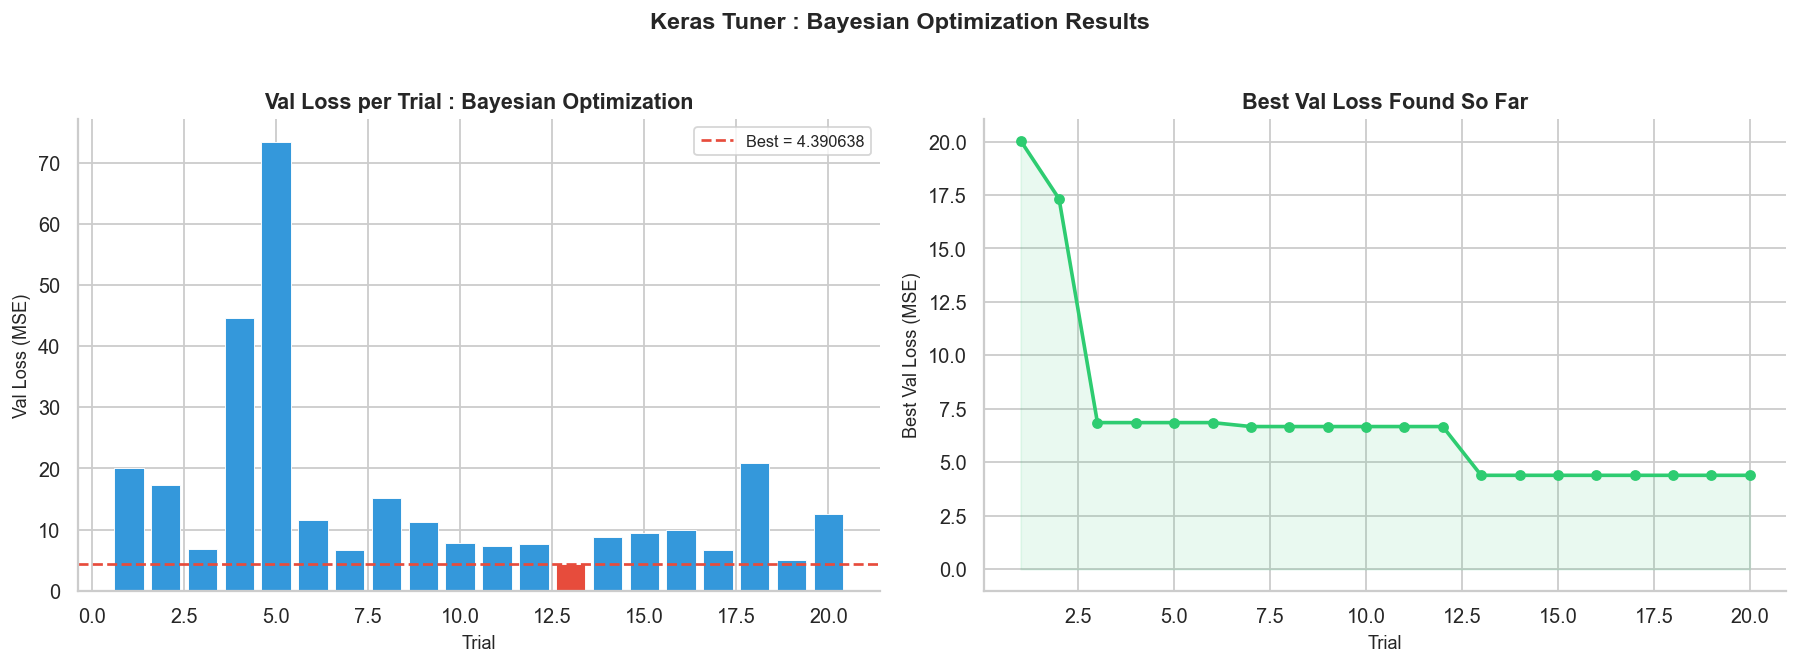

In [78]:
# ── Visualize all trials ──────────────────────────────────────
# Show how val_loss evolved across the 20 trials
# so we can see the Bayesian optimizer getting smarter over time

trials = tuner.oracle.trials
trial_ids  = list(trials.keys())
val_losses = []
lrs  = []

for tid in trial_ids:
    trial = trials[tid]
    if trial.score is not None:
        val_losses.append(trial.score)
        lrs.append(trial.hyperparameters.get("learning_rate"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left : val_loss per trial
axes[0].bar(range(1, len(val_losses) + 1), val_losses,
            color=["#e74c3c" if v == min(val_losses) else "#3498db"
                   for v in val_losses],
            edgecolor="white", linewidth=0.5)
axes[0].set_title("Val Loss per Trial : Bayesian Optimization",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Trial", fontsize=10)
axes[0].set_ylabel("Val Loss (MSE)", fontsize=10)
axes[0].axhline(min(val_losses), color="#e74c3c", linestyle="--",
                linewidth=1.5, label=f"Best = {min(val_losses):.6f}")
axes[0].legend(fontsize=9)

# Right : best val_loss found so far (shows Bayesian improving over time)
best_so_far = [min(val_losses[:i+1]) for i in range(len(val_losses))]
axes[1].plot(range(1, len(best_so_far) + 1), best_so_far,
             color="#2ecc71", linewidth=2, marker="o", markersize=5)
axes[1].set_title("Best Val Loss Found So Far",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Trial", fontsize=10)
axes[1].set_ylabel("Best Val Loss (MSE)", fontsize=10)
axes[1].fill_between(range(1, len(best_so_far) + 1),
                     best_so_far, alpha=0.1, color="#2ecc71")

plt.suptitle("Keras Tuner : Bayesian Optimization Results",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/keras_tuner_results.png", bbox_inches="tight")
plt.show()

## Step 6 : Final Training

Now that Keras Tuner found the best hyperparameters, we build the final
Autoencoder with those exact values and train it properly.

### What changes compared to the tuning phase :
- During tuning : max 50 epochs, patience 5 → fast evaluation per trial
- Now : max 100 epochs, patience 10 → full convergence allowed
- We also add **ModelCheckpoint** to save the best weights automatically

### Training configuration :

| Setting | Value |
|---|---|
| Loss function | Mean Squared Error (MSE) |
| Optimizer | Adam |
| Learning rate | Best from Keras Tuner |
| Encoder layer 1 | Best from Keras Tuner |
| Encoder layer 2 | Best from Keras Tuner |
| Bottleneck | Best from Keras Tuner |
| Dropout | Best from Keras Tuner |
| Max epochs | 100 |
| EarlyStopping patience | 10 |
| ReduceLROnPlateau | patience=5, factor=0.5 |

In [96]:
# Build final model with best hyperparameters from Keras Tuner
autoencoder = build_autoencoder(
    input_dim = INPUT_DIM,
    units_enc1 = BEST_UNITS_ENC1,
    units_enc2 = BEST_UNITS_ENC2,
    bottleneck = BEST_BOTTLENECK,
    dropout = BEST_DROPOUT,
    learning_rate = BEST_LR,
    l2_reg = BEST_L2
)

print("Final Autoencoder Architecture")
print("*" * 55)
print(f"Input dim : {INPUT_DIM}")
print(f"Encoder 1 : {BEST_UNITS_ENC1} neurons (relu)")
print(f"Encoder 2 : {BEST_UNITS_ENC2} neurons (relu)")
print(f"Bottleneck : {BEST_BOTTLENECK} neurons (relu)")
print(f"Decoder 1 : {BEST_UNITS_ENC2} neurons (relu)")
print(f"Decoder 2 : {BEST_UNITS_ENC1} neurons (relu)")
print(f"Output : {INPUT_DIM} neurons (linear)")
print(f"Dropout  : {BEST_DROPOUT}")
print(f"Learning rate : {BEST_LR}")
print("*" * 55)

autoencoder.summary()

Final Autoencoder Architecture
*******************************************************
Input dim : 46
Encoder 1 : 64 neurons (relu)
Encoder 2 : 32 neurons (relu)
Bottleneck : 8 neurons (relu)
Decoder 1 : 32 neurons (relu)
Decoder 2 : 64 neurons (relu)
Output : 46 neurons (linear)
Dropout  : 0.05
Learning rate : 0.001
*******************************************************


Model: "DeepAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 46)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 64)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_1 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_enc_2 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_2 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_1 (BatchNormalization)   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_1 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dec_2 (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,510 (44.96 KB)

 Trainable params: 11,126 (43.46 KB)

 Non-trainable params: 384 (1.50 KB)

In [97]:
import os

os.makedirs("../ml", exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="../ml/autoencoder_best_weights.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Deep Autoencoder — Final Training")
print("=" * 55)
print(f"  Learning rate : {BEST_LR}")
print(f"  Max epochs    : {EPOCHS}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Train samples : {len(X_train_np)} (normal only)")
print(f"  Val samples   : {len(X_val_np)}")
print("=" * 55)

t0 = time.time()

history = autoencoder.fit(
    X_train_np, X_train_np,       # input = output (reconstruction)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_np, X_val_np),
    callbacks=callbacks,
    verbose=1
)

elapsed    = time.time() - t0
epochs_done = len(history.history["loss"])

print(f"\n✅ Training complete")
print(f"  Epochs trained  : {epochs_done} / {EPOCHS}")
print(f"  Best val_loss   : {min(history.history['val_loss']):.6f}")
print(f"  Training time   : {elapsed:.1f}s ({elapsed/60:.1f} min)")

Deep Autoencoder — Final Training
  Learning rate : 0.001
  Max epochs    : 100
  Batch size    : 32
  Train samples : 2166 (normal only)
  Val samples   : 542
Epoch 1/100
58/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5752
Epoch 1: val_loss improved from None to 0.74177, saving model to ../ml/autoencoder_best_weights.keras

Epoch 1: finished saving model to ../ml/autoencoder_best_weights.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.2084 - val_loss: 0.7418 - learning_rate: 0.0010
Epoch 2/100
62/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7509
Epoch 2: val_loss improved from 0.74177 to 0.59666, saving model to ../ml/autoencoder_best_weights.keras

Epoch 2: finished saving model to ../ml/autoencoder_best_weights.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7009 - val_loss: 0.5967 - learning_rate: 0.0010
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5807
Epoch 3: val_loss improved from 0.59666 to 0.48178, saving model to ../ml/autoencoder_best_weigh

## Step 7 : Learning Curves

Learning curves show how the model improved over each training epoch.
We plot both training loss and validation loss on the same graph.

### What we look for :

| Pattern | Meaning |
|---|---|
| Both curves decreasing | Model is learning correctly |
| Train ≈ Val | No overfitting — model generalizes well |
| Val loss flattens, train keeps going down | Overfitting — EarlyStopping should have caught this |
| Both curves flat from the start | Learning rate too low or model too simple |

### Why does this matter for an Autoencoder ?

If the model overfits on normal data, it starts reconstructing everything too well —
including anomalies. This destroys the detection signal because anomalous windows
will also have low reconstruction error. A good learning curve shows the model
learned normal patterns without memorizing them.

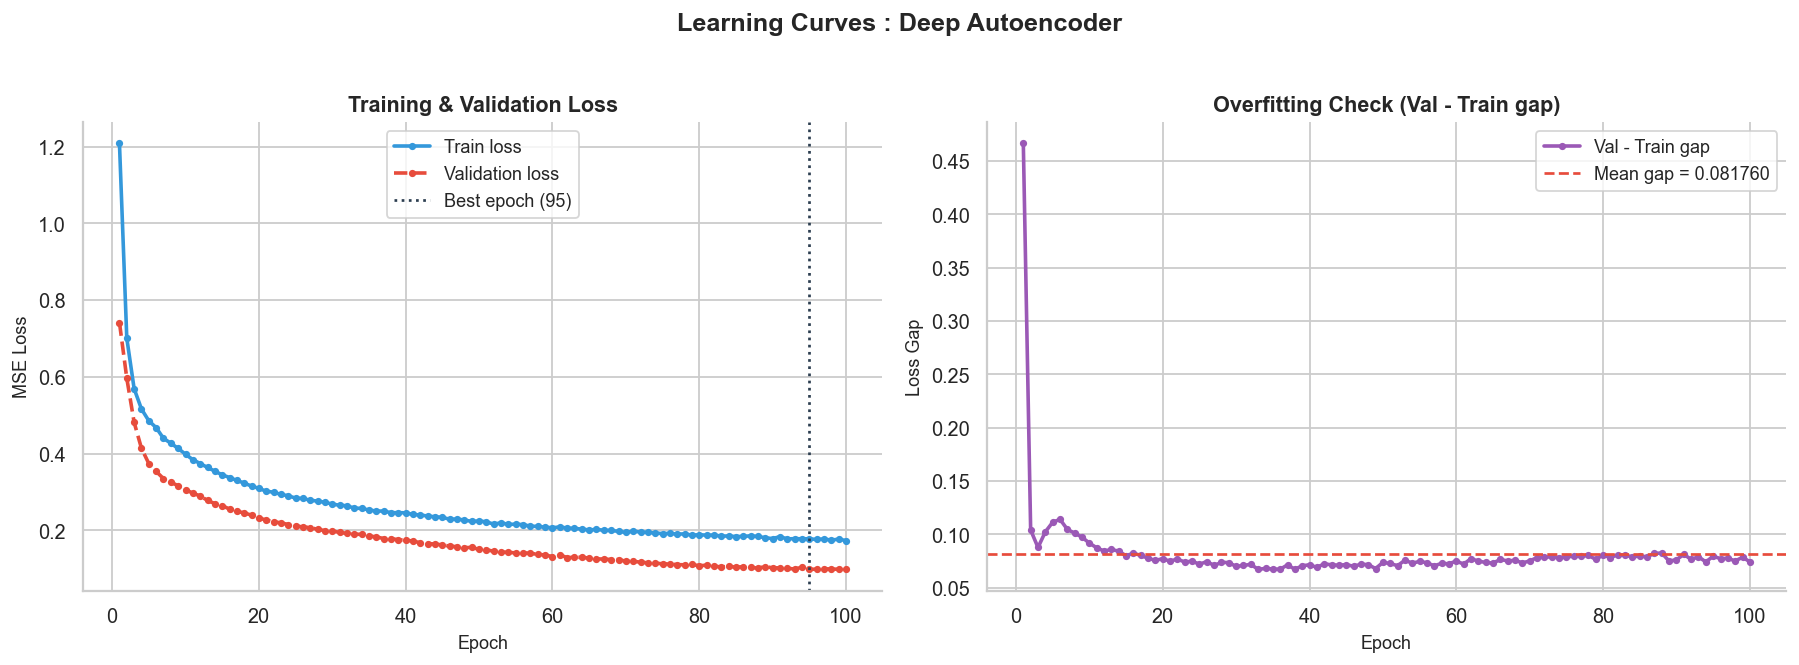

Best epoch      : 95
Best val_loss   : 0.098821
Final train_loss: 0.173635
Final val_loss  : 0.099260
Gap             : 0.074375
Some overfitting detected 


In [98]:
train_loss   = history.history["loss"]
val_loss     = history.history["val_loss"]
epochs_range = range(1, len(train_loss) + 1)
best_epoch   = int(np.argmin(val_loss)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left : full learning curve ────────────────────────────
axes[0].plot(epochs_range, train_loss,
             color="#3498db", linewidth=2,
             marker="o", markersize=3, label="Train loss")
axes[0].plot(epochs_range, val_loss,
             color="#e74c3c", linewidth=2,
             linestyle="--", marker="o", markersize=3, label="Validation loss")
axes[0].axvline(best_epoch, color="#2c3e50", linestyle=":",
                linewidth=1.5, label=f"Best epoch ({best_epoch})")
axes[0].set_title("Training & Validation Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=10)
axes[0].set_ylabel("MSE Loss", fontsize=10)
axes[0].legend(fontsize=10)

# ── Right : gap between train and val (overfitting check) ─
gap = [abs(v - t) for v, t in zip(val_loss, train_loss)]
axes[1].plot(epochs_range, gap,
             color="#9b59b6", linewidth=2,
             marker="o", markersize=3, label="Val - Train gap")
axes[1].axhline(np.mean(gap), color="#e74c3c", linestyle="--",
                linewidth=1.5, label=f"Mean gap = {np.mean(gap):.6f}")
axes[1].set_title("Overfitting Check (Val - Train gap)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=10)
axes[1].set_ylabel("Loss Gap", fontsize=10)
axes[1].legend(fontsize=10)

plt.suptitle("Learning Curves : Deep Autoencoder",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/learning_curves_autoencoder.png", bbox_inches="tight")
plt.show()

print(f"Best epoch      : {best_epoch}")
print(f"Best val_loss   : {min(val_loss):.6f}")
print(f"Final train_loss: {train_loss[-1]:.6f}")
print(f"Final val_loss  : {val_loss[-1]:.6f}")
print(f"Gap             : {abs(val_loss[-1] - train_loss[-1]):.6f}")

if abs(val_loss[-1] - train_loss[-1]) < 0.01:
    print("No significant overfitting detected")
else:
    print("Some overfitting detected ")

In [99]:
print(f"Train loss epoch 1  : {train_loss[0]:.6f}")
print(f"Train loss last     : {train_loss[-1]:.6f}")
print(f"Val loss epoch 1    : {val_loss[0]:.6f}")
print(f"Val loss last       : {val_loss[-1]:.6f}")
print(f"Gap epoch 1         : {abs(val_loss[0] - train_loss[0]):.6f}")
print(f"Gap last epoch      : {abs(val_loss[-1] - train_loss[-1]):.6f}")

Train loss epoch 1  : 1.208355
Train loss last     : 0.173635
Val loss epoch 1    : 0.741775
Val loss last       : 0.099260
Gap epoch 1         : 0.466580
Gap last epoch      : 0.074375


## Step 8 : Reconstruction Error & Anomaly Threshold

After training, the Autoencoder can reconstruct any input window.
For each window we compute the **Mean Squared Error (MSE)** between
the original input and its reconstruction. This MSE is our **anomaly score**.

### The core idea :

The model was trained ONLY on normal windows. So :
- Normal window → model knows how to reconstruct it well → **low MSE** ✅
- Anomalous window → model never saw this pattern → reconstruction fails → **high MSE** 🚨

### How we define the threshold :

We compute reconstruction errors on the **training normal data** and take
the **95th percentile** as our starting threshold. This means :
- 95% of normal windows score below the threshold → classified as normal
- Any window above the threshold → flagged as anomaly

This threshold will then be **optimized in Step 10** by testing all
percentiles from 80 to 99 and picking the one that maximizes F1 Score.

In [100]:
# ── Reconstruction errors on TRAINING normal data → defines threshold ──
train_recon  = autoencoder.predict(X_train_np, verbose=0)
train_errors = np.mean(np.power(X_train_np - train_recon, 2), axis=1)

# ── Reconstruction errors on TEST data → used for evaluation ──
test_recon  = autoencoder.predict(X_test_np, verbose=0)
test_errors = np.mean(np.power(X_test_np - test_recon, 2), axis=1)

# ── Starting threshold = 95th percentile of normal errors ──
THRESHOLD = np.percentile(train_errors, THRESHOLD_PCT)

print(f"Reconstruction errors computed")
print(f"\n=== TRAINING (normal only) ===")
print(f"  Min    : {train_errors.min():.6f}")
print(f"  Mean   : {train_errors.mean():.6f}")
print(f"  Median : {np.median(train_errors):.6f}")
print(f"  P95    : {THRESHOLD:.6f}  ← starting threshold")
print(f"  Max    : {train_errors.max():.6f}")

print(f"\n=== TEST (normal + anomalies) ===")
print(f"  Min    : {test_errors.min():.6f}")
print(f"  Mean   : {test_errors.mean():.6f}")
print(f"  Median : {np.median(test_errors):.6f}")
print(f"  Max    : {test_errors.max():.6f}")

# How many test windows would be flagged with this threshold ?
flagged = (test_errors > THRESHOLD).sum()
print(f"\n  Windows flagged as anomaly : {flagged} / {len(test_errors)}")
print(f"  Flag rate                  : {flagged/len(test_errors)*100:.1f}%")

Reconstruction errors computed

=== TRAINING (normal only) ===
  Min    : 0.003872
  Mean   : 0.087316
  Median : 0.052335
  P95    : 0.267572  ← starting threshold
  Max    : 1.779951

=== TEST (normal + anomalies) ===
  Min    : 0.005394
  Mean   : 45.143208
  Median : 0.053754
  Max    : 2789.912109

  Windows flagged as anomaly : 89 / 889
  Flag rate                  : 10.0%


### Visualizing the reconstruction error distribution

We plot the distribution of reconstruction errors separately for
normal and anomalous windows in the test set.

A good Autoencoder should show :
- Normal errors → clustered at low values (left)
- Anomaly errors → spread at higher values (right)
- A visible separation between the two distributions

If the two distributions overlap heavily, it means the model struggles
to distinguish normal from anomalous windows — which can happen when
anomalies are subtle or the dataset is too small.

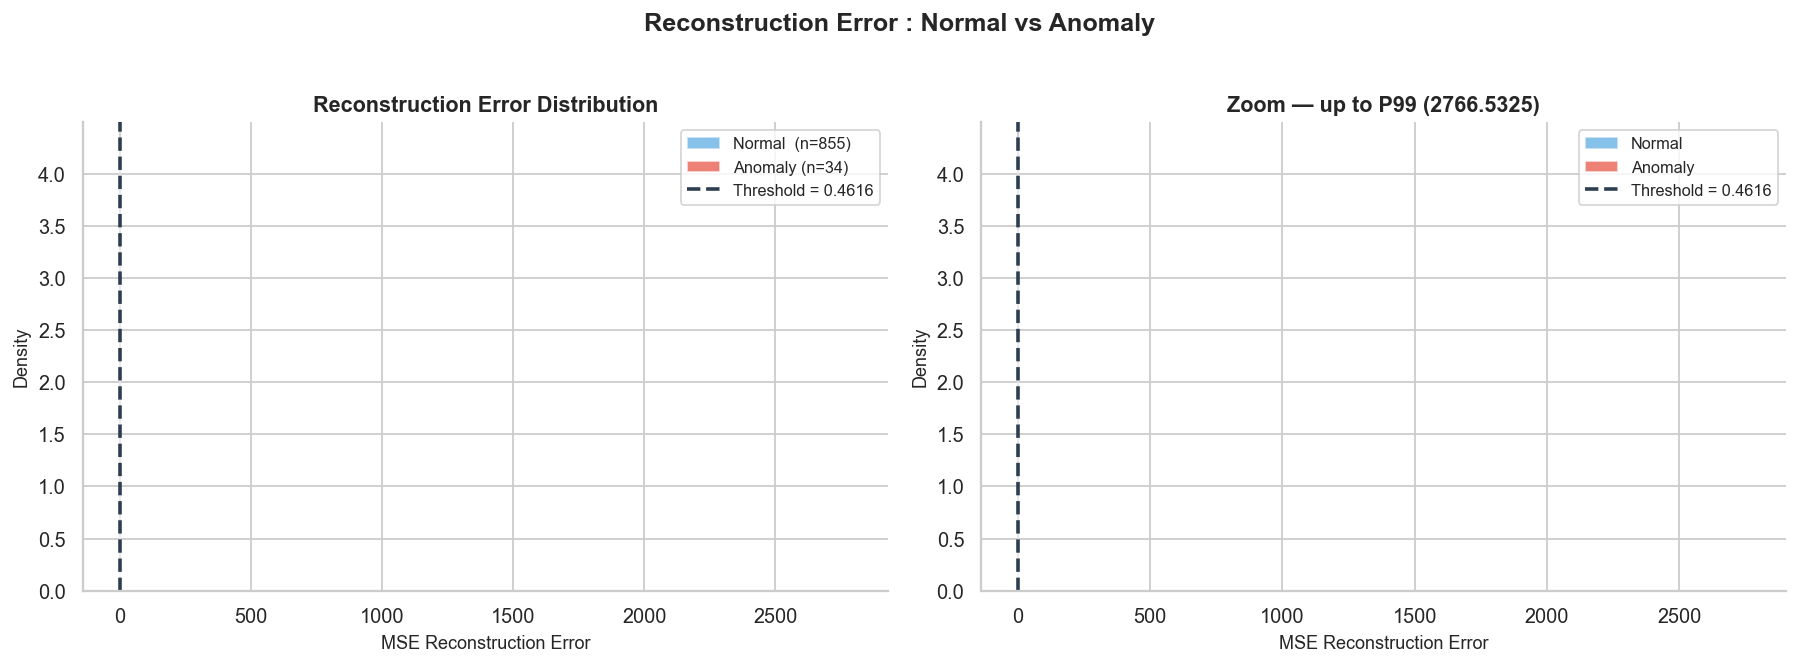

Normal errors  — mean : 0.096917
Anomaly errors — mean : 1177.925049

✅ Anomaly errors are higher than normal errors — detection signal exists


In [115]:
normal_errors  = test_errors[y_test.values == 0]
anomaly_errors = test_errors[y_test.values == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left : full distribution ───────────────────────────────
axes[0].hist(normal_errors,  bins=40, alpha=0.6,
             color="#3498db", edgecolor="white",
             density=True, label=f"Normal  (n={len(normal_errors)})")
axes[0].hist(anomaly_errors, bins=40, alpha=0.7,
             color="#e74c3c", edgecolor="white",
             density=True, label=f"Anomaly (n={len(anomaly_errors)})")
axes[0].axvline(THRESHOLD, color="#2c3e50", linestyle="--",
                linewidth=2, label=f"Threshold = {THRESHOLD:.4f}")
axes[0].set_title("Reconstruction Error Distribution",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("MSE Reconstruction Error", fontsize=10)
axes[0].set_ylabel("Density", fontsize=10)
axes[0].legend(fontsize=9)

# ── Right : zoom on P99 to see separation more clearly ────
zoom_max = np.percentile(test_errors, 99)
axes[1].hist(normal_errors[normal_errors   <= zoom_max], bins=40,
             alpha=0.6, color="#3498db", edgecolor="white",
             density=True, label="Normal")
axes[1].hist(anomaly_errors[anomaly_errors <= zoom_max], bins=40,
             alpha=0.7, color="#e74c3c", edgecolor="white",
             density=True, label="Anomaly")
axes[1].axvline(THRESHOLD, color="#2c3e50", linestyle="--",
                linewidth=2, label=f"Threshold = {THRESHOLD:.4f}")
axes[1].set_title(f"Zoom — up to P99 ({zoom_max:.4f})",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("MSE Reconstruction Error", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle("Reconstruction Error : Normal vs Anomaly",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/reconstruction_errors.png", bbox_inches="tight")
plt.show()

print(f"Normal errors  — mean : {normal_errors.mean():.6f}")
print(f"Anomaly errors — mean : {anomaly_errors.mean():.6f}")

if anomaly_errors.mean() > normal_errors.mean():
    print("\n✅ Anomaly errors are higher than normal errors — detection signal exists")
else:
    print("\n⚠️  Anomaly errors are NOT higher — model may not separate classes well")

## Step 9 : Threshold Sensitivity Analysis

The threshold we defined in Step 8 (P95 = 0.0302) flagged 98 windows
but only 39 are real anomalies — too many false alarms.

Instead of fixing the threshold manually, we test **every percentile
from 80 to 99** and measure how Precision, Recall, and F1 change.

### The trade-off :

| Threshold | Effect |
|---|---|
| Too low (P80-P85) | Flags many windows → high Recall, low Precision (many false alarms) |
| Too high (P96-P99) | Flags few windows → high Precision, low Recall (misses real anomalies) |
| **Optimal** | **Maximizes F1 — best balance between the two** |

### Why F1 and not just Accuracy ?

With 850 normal and only 39 anomalies, a model that flags nothing
would have 850/889 = 95.6% accuracy — but it catches zero anomalies.
F1 is immune to this trap because it considers both Precision and Recall.

In [101]:
percentiles = range(80, 100)
f1_scores   = []
precisions  = []
recalls     = []
thresholds  = []
flag_rates  = []

for pct in percentiles:
    thresh  = np.percentile(train_errors, pct)
    y_pred  = (test_errors > thresh).astype(int)

    f1_scores.append(f1_score(y_test, y_pred, zero_division=0))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))
    thresholds.append(thresh)
    flag_rates.append(y_pred.mean() * 100)

# ── Find best percentile ───────────────────────────────────
best_idx        = int(np.argmax(f1_scores))
BEST_THRESHOLD  = thresholds[best_idx]
BEST_PERCENTILE = list(percentiles)[best_idx]

print("=== SENSITIVITY ANALYSIS RESULTS ===\n")
print(f"{'Pct':>4} | {'Threshold':>10} | {'F1':>6} | {'Precision':>9} | {'Recall':>6} | {'Flag%':>6}")
print("-" * 55)
for i, pct in enumerate(percentiles):
    mark = " ← BEST" if i == best_idx else ""
    print(f"  P{pct} | {thresholds[i]:>10.6f} | {f1_scores[i]:>6.3f} | "
          f"{precisions[i]:>9.3f} | {recalls[i]:>6.3f} | "
          f"{flag_rates[i]:>5.1f}%{mark}")

print(f"Best threshold : {BEST_THRESHOLD:.6f} (P{BEST_PERCENTILE})")
print(f"   Best F1        : {f1_scores[best_idx]:.3f}")
print(f"   Precision      : {precisions[best_idx]:.3f}")
print(f"   Recall         : {recalls[best_idx]:.3f}")

=== SENSITIVITY ANALYSIS RESULTS ===

 Pct |  Threshold |     F1 | Precision | Recall |  Flag%
-------------------------------------------------------
  P80 |   0.136096 |  0.305 |     0.180 |  1.000 |  21.3%
  P81 |   0.138617 |  0.308 |     0.182 |  1.000 |  21.0%
  P82 |   0.144543 |  0.319 |     0.190 |  1.000 |  20.1%
  P83 |   0.150375 |  0.332 |     0.199 |  1.000 |  19.2%
  P84 |   0.154923 |  0.349 |     0.211 |  1.000 |  18.1%
  P85 |   0.159446 |  0.356 |     0.217 |  1.000 |  17.7%
  P86 |   0.165360 |  0.372 |     0.228 |  1.000 |  16.8%
  P87 |   0.171269 |  0.386 |     0.239 |  1.000 |  16.0%
  P88 |   0.176940 |  0.400 |     0.250 |  1.000 |  15.3%
  P89 |   0.182939 |  0.412 |     0.260 |  1.000 |  14.7%
  P90 |   0.190761 |  0.436 |     0.279 |  1.000 |  13.7%
  P91 |   0.204898 |  0.463 |     0.301 |  1.000 |  12.7%
  P92 |   0.212893 |  0.476 |     0.312 |  1.000 |  12.3%
  P93 |   0.229265 |  0.504 |     0.337 |  1.000 |  11.4%
  P94 |   0.239087 |  0.511 |     0.3

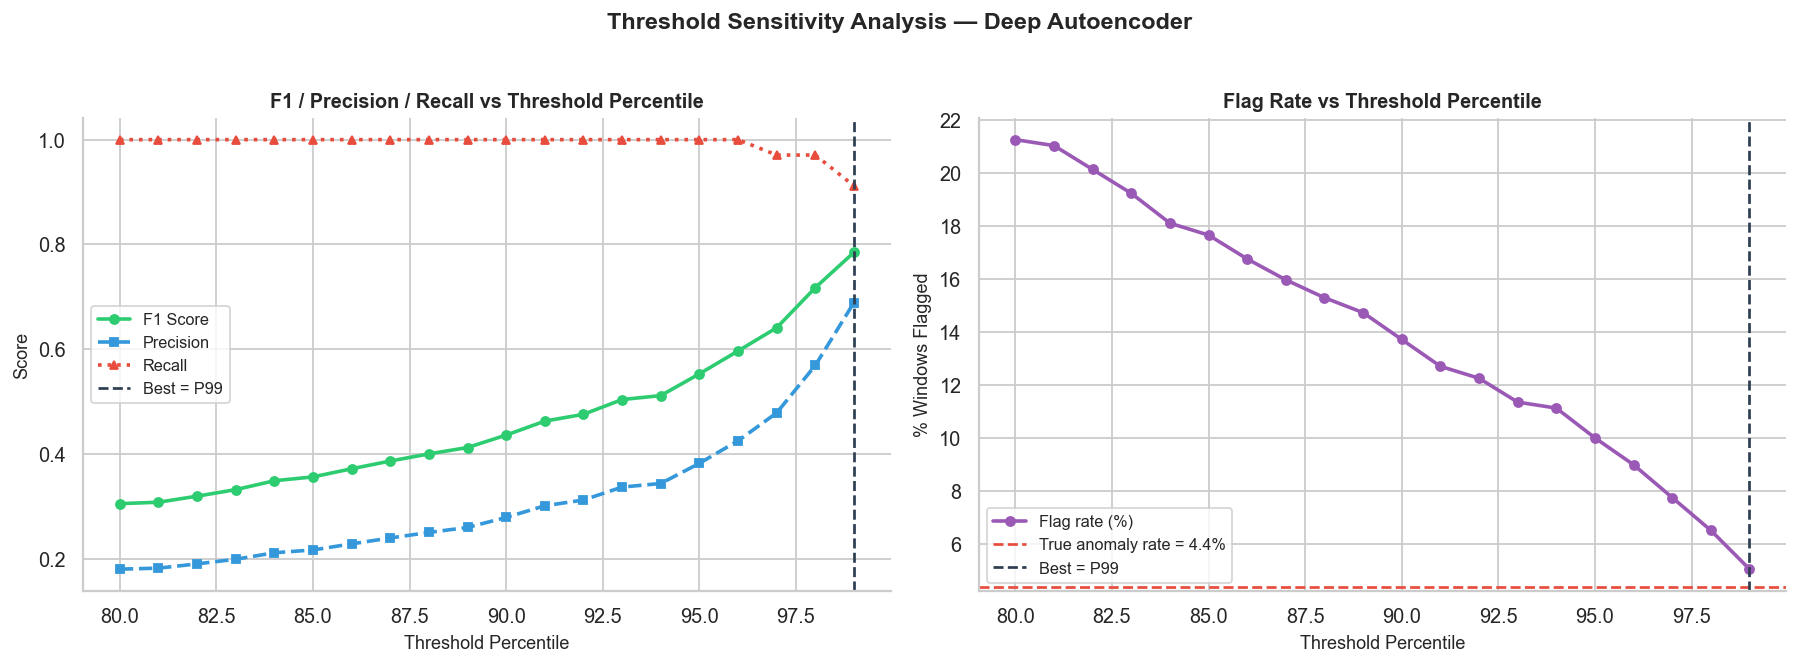


✅ THRESHOLD updated to 0.461638 (P99)


In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pct_list = list(percentiles)

# ── Left : F1 / Precision / Recall vs percentile ──────────
axes[0].plot(pct_list, f1_scores,  color="#2ecc71", linewidth=2,
             marker="o", markersize=5, label="F1 Score")
axes[0].plot(pct_list, precisions, color="#3498db", linewidth=2,
             linestyle="--", marker="s", markersize=4, label="Precision")
axes[0].plot(pct_list, recalls,    color="#e74c3c", linewidth=2,
             linestyle=":", marker="^", markersize=4, label="Recall")
axes[0].axvline(BEST_PERCENTILE, color="#2c3e50", linestyle="--",
                linewidth=1.5, label=f"Best = P{BEST_PERCENTILE}")
axes[0].set_title("F1 / Precision / Recall vs Threshold Percentile",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Threshold Percentile", fontsize=10)
axes[0].set_ylabel("Score", fontsize=10)
axes[0].legend(fontsize=9)

# ── Right : Flag rate vs percentile ───────────────────────
axes[1].plot(pct_list, flag_rates, color="#9b59b6", linewidth=2,
             marker="o", markersize=5, label="Flag rate (%)")
axes[1].axhline(39/889*100, color="#e74c3c", linestyle="--",
                linewidth=1.5,
                label=f"True anomaly rate = {39/889*100:.1f}%")
axes[1].axvline(BEST_PERCENTILE, color="#2c3e50", linestyle="--",
                linewidth=1.5, label=f"Best = P{BEST_PERCENTILE}")
axes[1].set_title("Flag Rate vs Threshold Percentile",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Threshold Percentile", fontsize=10)
axes[1].set_ylabel("% Windows Flagged", fontsize=10)
axes[1].legend(fontsize=9)

plt.suptitle("Threshold Sensitivity Analysis — Deep Autoencoder",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/threshold_sensitivity.png", bbox_inches="tight")
plt.show()

# Update threshold with the optimal value
THRESHOLD = BEST_THRESHOLD
print(f"\n✅ THRESHOLD updated to {THRESHOLD:.6f} (P{BEST_PERCENTILE})")

## Step 10 : Evaluation — Metrics, Confusion Matrix & ROC Curve

Now that we have the optimal threshold from Step 9, we evaluate the
final model on the test set using all standard metrics.

### Metrics explained :

| Metric | Formula | Meaning |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all windows flagged, how many were real anomalies ? |
| **Recall** | TP / (TP + FN) | Of all real anomalies, how many did we catch ? |
| **F1 Score** | 2 × P × R / (P + R) | Harmonic mean — main metric for imbalanced data |
| **ROC AUC** | Area under ROC curve | Threshold-independent performance measure |

### Which metric matters most here ?

In API monitoring, **missing a real anomaly is more dangerous than a false alarm**.
A false alarm costs an engineer a few minutes of investigation.
A missed anomaly can cause hours of downtime and impact thousands of users.

This means **Recall is our priority** — we prefer to catch all anomalies
even if it means some false alarms, as long as Precision stays reasonable.

In [103]:
# ── Final predictions with optimal threshold ───────────────
y_pred    = (test_errors > THRESHOLD).astype(int)

precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
auc_score = roc_auc_score(y_test, test_errors)

print("=" * 55)
print("   FINAL RESULTS — DEEP AUTOENCODER")
print("=" * 55)
print(f"  Threshold   : {THRESHOLD:.6f}  (P{BEST_PERCENTILE})")
print(f"  Precision   : {precision:.3f}")
print(f"  Recall      : {recall:.3f}")
print(f"  F1 Score    : {f1:.3f}")
print(f"  ROC AUC     : {auc_score:.3f}")
print("=" * 55)
print()
print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Anomaly"]
))

   FINAL RESULTS — DEEP AUTOENCODER
  Threshold   : 0.461638  (P99)
  Precision   : 0.689
  Recall      : 0.912
  F1 Score    : 0.785
  ROC AUC     : 0.996

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       855
     Anomaly       0.69      0.91      0.78        34

    accuracy                           0.98       889
   macro avg       0.84      0.95      0.89       889
weighted avg       0.98      0.98      0.98       889



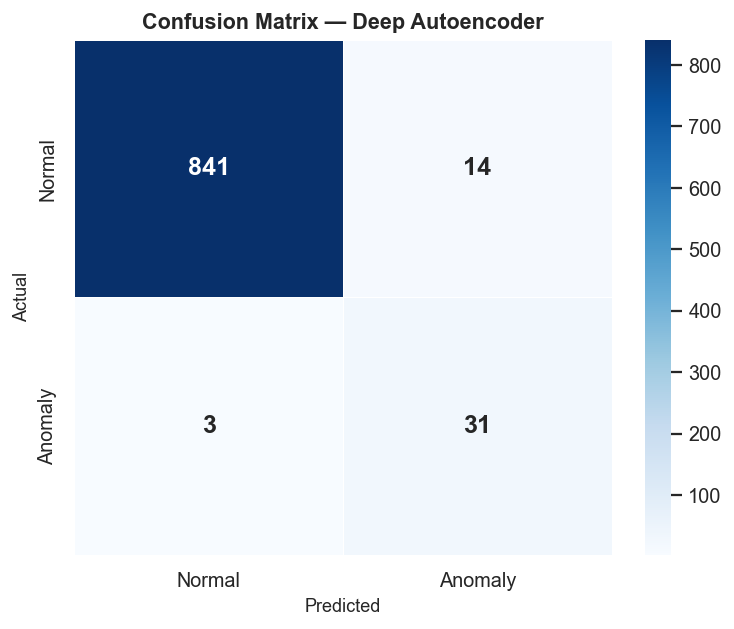

True Negatives  (Normal  → Normal ) :  841  ✅ correctly ignored
False Positives (Normal  → Anomaly) :   14  ⚠️  false alarm
False Negatives (Anomaly → Normal ) :    3  ❌ missed anomaly
True Positives  (Anomaly → Anomaly) :   31  ✅ caught!

False alarm rate  : 1.6%
Miss rate         : 8.8%


In [110]:
# ── Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"],
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 14, "weight": "bold"}
)
ax.set_title("Confusion Matrix — Deep Autoencoder",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual", fontsize=10)
plt.tight_layout()
plt.savefig("../report/confusion_matrix_autoencoder.png", bbox_inches="tight")
plt.show()

print(f"True Negatives  (Normal  → Normal ) : {tn:>4}  ✅ correctly ignored")
print(f"False Positives (Normal  → Anomaly) : {fp:>4}  ⚠️  false alarm")
print(f"False Negatives (Anomaly → Normal ) : {fn:>4}  ❌ missed anomaly")
print(f"True Positives  (Anomaly → Anomaly) : {tp:>4}  ✅ caught!")
print(f"\nFalse alarm rate  : {fp/(fp+tn)*100:.1f}%")
print(f"Miss rate         : {fn/(fn+tp)*100:.1f}%")

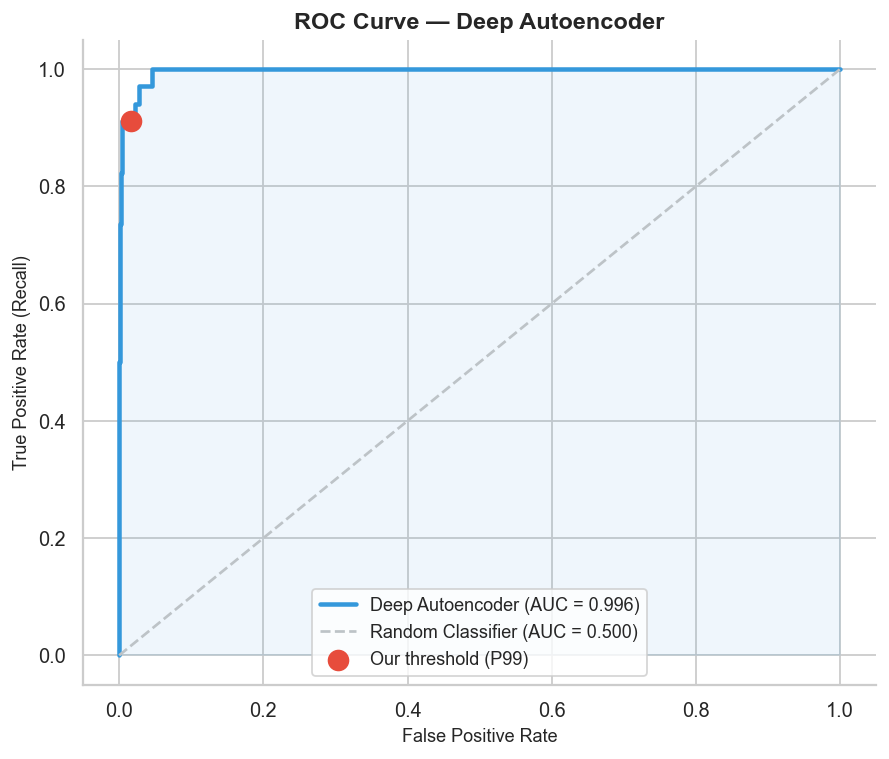

ROC AUC : 0.996
✅ Excellent — model separates normal from anomaly very well


In [111]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_errors)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color="#3498db", linewidth=2.5,
        label=f"Deep Autoencoder (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="#bdc3c7", linestyle="--",
        linewidth=1.5, label="Random Classifier (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#3498db")

# Mark the operating point (our chosen threshold)
ax.scatter(fp/(fp+tn), tp/(tp+fn), color="#e74c3c",
           s=120, zorder=5, label=f"Our threshold (P{BEST_PERCENTILE})")

ax.set_title("ROC Curve — Deep Autoencoder",
             fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate", fontsize=10)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../report/roc_curve_autoencoder.png", bbox_inches="tight")
plt.show()

print(f"ROC AUC : {auc_score:.3f}")
if auc_score >= 0.90:
    print("✅ Excellent — model separates normal from anomaly very well")
elif auc_score >= 0.80:
    print("✅ Good — model has solid detection capability")
elif auc_score >= 0.70:
    print("⚠️  Fair — model detects some anomalies but misses others")
else:
    print("❌ Poor — model struggles to separate normal from anomaly")

In [113]:
import os
import json
import pickle
import datetime

os.makedirs("../ml", exist_ok=True)

# ── 1. Save Keras model ────────────────────────────────────
autoencoder.save("../ml/autoencoder_model.keras")

# ── 2. Save metadata (threshold, metrics, features, preprocessing) ──
model_metadata = {
    # Decision threshold
    "threshold": float(THRESHOLD),
    "threshold_percentile": int(BEST_PERCENTILE),

    # Architecture
    "input_dim": int(INPUT_DIM),
    "features": list(X_train.columns),

    # Preprocessing — CRITICAL for correct inference
    "preprocessing": {
        "clip_columns": COLS_TO_CLIP,
        "clip_bounds_file": "clip_bounds.pkl",
        "scaler_file": "scaler.pkl",
        "order": ["clip", "scale", "predict"]
    },

    # Hyperparameters used
    "hyperparameters": {
        "units_enc1": int(BEST_UNITS_ENC1),
        "units_enc2": int(BEST_UNITS_ENC2),
        "bottleneck": int(BEST_BOTTLENECK),
        "dropout": float(BEST_DROPOUT),
        "learning_rate": float(BEST_LR),
        "l2_reg": float(BEST_L2),
    },

    # Test set performance
    "metrics": {
        "f1"        : round(float(f1), 4),
        "precision" : round(float(precision), 4),
        "recall"    : round(float(recall), 4),
        "auc"       : round(float(auc_score), 4),
        "true_negatives"  : int(tn),
        "false_positives" : int(fp),
        "false_negatives" : int(fn),
        "true_positives"  : int(tp),
    },

    # Traceability
    "trained_on"    : datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "train_samples" : int(len(X_train_np)),
    "test_samples"  : int(len(X_test_np)),
    "dataset"       : "mindweave/web-server-logs",
    "model_file"    : "autoencoder_model.keras",
}

with open("../ml/autoencoder_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

# ── 3. Verify scaler.pkl and clip_bounds.pkl exist ─────────
print("✅ All artifacts saved :")
print(f"  - ../ml/autoencoder_model.keras")
print(f"  - ../ml/autoencoder_metadata.json")
print(f"  - ../data/scaler.pkl")
print(f"  - ../data/clip_bounds.pkl")

print(f"\n=== ARTIFACT SUMMARY ===")
print(f"  Threshold       : {model_metadata['threshold']:.6f}  (P{model_metadata['threshold_percentile']})")
print(f"  Input dim       : {model_metadata['input_dim']}")
print(f"  Clipped columns : {model_metadata['preprocessing']['clip_columns']}")
print(f"  Precision       : {model_metadata['metrics']['precision']}")
print(f"  Recall          : {model_metadata['metrics']['recall']}")
print(f"  F1              : {model_metadata['metrics']['f1']}")
print(f"  AUC             : {model_metadata['metrics']['auc']}")

✅ All artifacts saved :
  - ../ml/autoencoder_model.keras
  - ../ml/autoencoder_metadata.json
  - ../data/scaler.pkl
  - ../data/clip_bounds.pkl

=== ARTIFACT SUMMARY ===
  Threshold       : 0.461638  (P99)
  Input dim       : 46
  Clipped columns : ['quality_degradation']
  Precision       : 0.6889
  Recall          : 0.9118
  F1              : 0.7848
  AUC             : 0.9964


In [ ]:
# ── Verify artifacts load correctly ───────────────────────
# Simulate exactly what the Flask microservice will do at startup + inference

from tensorflow.keras.models import load_model

print("=== VERIFICATION — simulating Flask startup ===\n")

# Load model
loaded_model = load_model("../ml/autoencoder_model.keras")
print("✅ autoencoder_model.keras loaded successfully")

# Load metadata
with open("../ml/autoencoder_metadata.json", "r") as f:
    loaded_meta = json.load(f)
print(f"✅ autoencoder_metadata.json loaded — threshold = {loaded_meta['threshold']:.6f}")

# Load scaler
with open("../data/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)
print(f"✅ scaler.pkl loaded — {len(loaded_meta['features'])} features")

# Load clip bounds
with open("../data/clip_bounds.pkl", "rb") as f:
    loaded_clip_bounds = pickle.load(f)
print(f"✅ clip_bounds.pkl loaded — columns: {list(loaded_clip_bounds.keys())}")

# ── Full inference pipeline simulation on one raw test sample ──
sample_raw = X_test.iloc[[0]].copy()   # raw, unclipped, unscaled

# Step 1 : clip
for col, (low, high) in loaded_clip_bounds.items():
    sample_raw[col] = sample_raw[col].clip(lower=low, upper=high)

# Step 2 : scale
sample_scaled = loaded_scaler.transform(sample_raw).astype("float32")

# Step 3 : predict + compute error
recon      = loaded_model.predict(sample_scaled, verbose=0)
error      = float(np.mean(np.power(sample_scaled - recon, 2)))
is_anomaly = error > loaded_meta["threshold"]

print(f"\n=== FULL PIPELINE TEST (one raw sample) ===")
print(f"  Reconstruction error : {error:.6f}")
print(f"  Threshold            : {loaded_meta['threshold']:.6f}")
print(f"  Prediction           : {'🚨 ANOMALY' if is_anomaly else '✅ NORMAL'}")
print(f"  Actual label         : {'🚨 ANOMALY' if y_test.iloc[0] == 1 else '✅ NORMAL'}")

=== VERIFICATION — simulating Flask startup ===

✅ autoencoder_model.keras loaded successfully
✅ autoencoder_metadata.json loaded — threshold = 0.461638
✅ scaler.pkl loaded — 46 features
✅ clip_bounds.pkl loaded — columns: ['quality_degradation']

=== FULL PIPELINE TEST (one raw sample) ===
  Reconstruction error : 0.101113
  Threshold            : 0.461638
  Prediction           : ✅ NORMAL
  Actual label         : ✅ NORMAL


In [116]:
# ── Test de robustesse — évaluation avec bruit injecté ────────
# En production, les logs arrivent avec du bruit : valeurs aberrantes,
# timestamps manquants, capteurs défaillants. On vérifie que le modèle
# reste stable quand les données sont légèrement corrompues.

from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

print("=" * 55)
print("   ROBUSTNESS TEST — Noise Injection")
print("=" * 55)

noise_levels = [0.01, 0.05, 0.10, 0.20]  # 1%, 5%, 10%, 20% de bruit

results = []
baseline_f1 = f1_score(y_test, y_pred)

for noise in noise_levels:
    # Injecter du bruit gaussien sur le test set
    X_test_noisy = X_test_np + np.random.normal(0, noise, X_test_np.shape)

    # Recalculer les erreurs de reconstruction
    X_test_recon_noisy = autoencoder.predict(X_test_noisy, verbose=0)
    errors_noisy = np.mean(np.power(X_test_noisy - X_test_recon_noisy, 2), axis=1)

    # Appliquer le même threshold
    y_pred_noisy = (errors_noisy > THRESHOLD).astype(int)

    f1_noisy  = f1_score(y_test, y_pred_noisy, zero_division=0)
    prec_noisy = precision_score(y_test, y_pred_noisy, zero_division=0)
    rec_noisy  = recall_score(y_test, y_pred_noisy, zero_division=0)
    drop       = baseline_f1 - f1_noisy

    results.append({
        "noise": noise,
        "f1": f1_noisy,
        "precision": prec_noisy,
        "recall": rec_noisy,
        "f1_drop": drop
    })

    status = "✅" if drop < 0.10 else "⚠️" if drop < 0.20 else "❌"
    print(f"Noise {noise*100:4.0f}% | F1={f1_noisy:.3f} | "
          f"P={prec_noisy:.3f} | R={rec_noisy:.3f} | "
          f"Drop={drop:.3f} {status}")

print("-" * 55)
print(f"Baseline (no noise) | F1={baseline_f1:.3f}")
print()

# Verdict global
max_drop = max(r["f1_drop"] for r in results[:2])  # sur 1% et 5%
if max_drop < 0.10:
    print("✅ Modèle ROBUSTE — dégradation < 10% avec bruit réaliste (1-5%)")
elif max_drop < 0.20:
    print("⚠️  Modèle ACCEPTABLE — dégradation modérée, surveiller en production")
else:
    print("❌ Modèle FRAGILE — trop sensible au bruit, revoir le preprocessing")

   ROBUSTNESS TEST — Noise Injection
Noise    1% | F1=0.785 | P=0.689 | R=0.912 | Drop=0.000 ✅
Noise    5% | F1=0.785 | P=0.689 | R=0.912 | Drop=0.000 ✅
Noise   10% | F1=0.762 | P=0.640 | R=0.941 | Drop=0.023 ✅
Noise   20% | F1=0.721 | P=0.596 | R=0.912 | Drop=0.064 ✅
-------------------------------------------------------
Baseline (no noise) | F1=0.785

✅ Modèle ROBUSTE — dégradation < 10% avec bruit réaliste (1-5%)
